# COVID-19 CHATBOT - 01 EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('OK')

OK


## 1. Load Data

In [2]:
df = pd.read_csv('/mnt/c/Users/remim/Documents/Ynov/Machine Learning/Projet/kaggle/Cleaned-Data.csv')
print(f'Dataset: {df.shape}')

Dataset: (316800, 27)


## 2. Data Quality

In [3]:
print(f'Missing: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

Missing: 0
Duplicates: 0


## 3. Severity Columns

In [4]:
severity_cols = [col for col in df.columns if 'severity' in col.lower()]
print(f'Found: {severity_cols}')

Found: ['Severity_Mild', 'Severity_Moderate', 'Severity_None', 'Severity_Severe']


## 4. Create Target

In [5]:
target = []
for idx, row in df.iterrows():
    if row['Severity_None'] == 1:
        target.append(0)
    elif row['Severity_Mild'] == 1:
        target.append(1)
    elif row['Severity_Moderate'] == 1:
        target.append(2)
    elif row['Severity_Severe'] == 1:
        target.append(3)
    else:
        target.append(-1)
df['Severity_Class'] = target
print('Target created')

Target created


## 5. Class Distribution

In [6]:
class_dist = df['Severity_Class'].value_counts().sort_index()
print(class_dist)

Severity_Class
0    79200
1    79200
2    79200
3    79200
Name: count, dtype: int64


## 6. Visualize

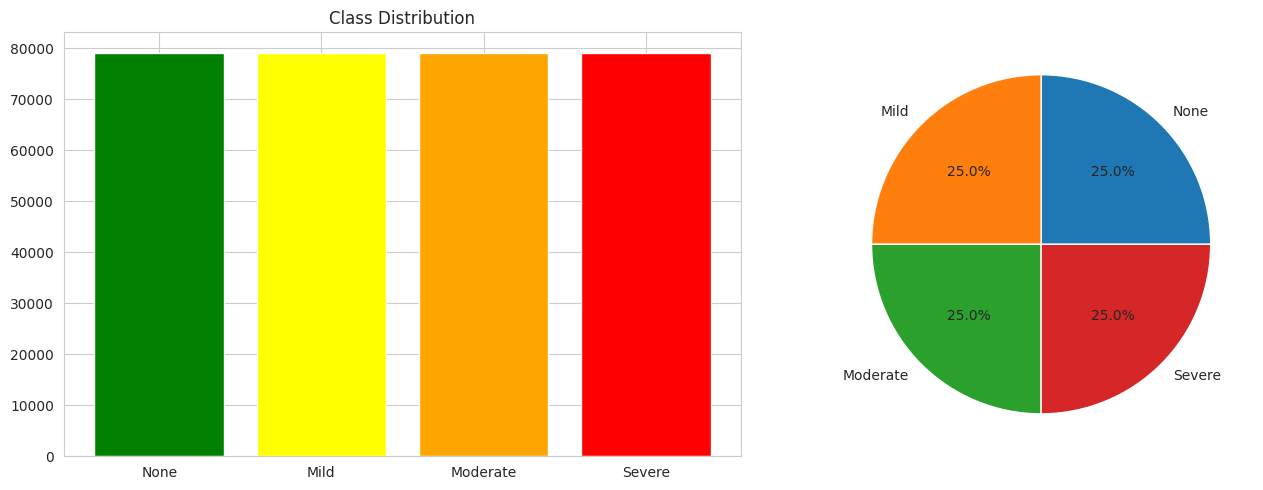

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['None', 'Mild', 'Moderate', 'Severe']
values = [class_dist[i] for i in range(4)]
axes[0].bar(labels, values, color=['green', 'yellow', 'orange', 'red'])
axes[0].set_title('Class Distribution')
axes[1].pie(values, labels=labels, autopct='%1.1f%%')
plt.tight_layout()
plt.savefig('01_class_distribution.png')
plt.show()

## 7. Save

In [8]:
df.to_csv('dataset_with_target.csv', index=False)
print('Saved')

Saved
